In [1]:
import pandas as pd
from datasets import Dataset
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
from transformers.utils.notebook import NotebookProgressCallback
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import torch
import matplotlib.pyplot as plt

# GPU check
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available.")

# Ensure reproducibility across runs
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU: NVIDIA GeForce RTX 4080


In [2]:
df = pd.read_csv('../datasets/smishing.csv')
df = df[["LABEL", "TEXT"]]
df["label"] = df["LABEL"].apply(lambda x: 0 if x == "ham" else 1)
dataset = Dataset.from_pandas(df)

In [3]:
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

Loading weights:   0%|                                                                                                                                                                                                                                                           | 0/100 [00:00<?, ?it/s]

Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 2004.56it/s]


DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [4]:
def tokenize(batch):
    return tokenizer(batch["TEXT"], padding="max_length", truncation=True)

dataset = dataset.map(tokenize, batched=True)
split = dataset.train_test_split(test_size=0.2, seed=42)
test_dataset = split["test"]

Map:   0%|                                                                                                                                                                                                                                                               | 0/5971 [00:00<?, ? examples/s]

Map:  17%|████████████████████████████████████████▌                                                                                                                                                                                                         | 1000/5971 [00:00<00:00, 9702.73 examples/s]

Map:  84%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊                                       | 5000/5971 [00:00<00:00, 18494.47 examples/s]

Map: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5971/5971 [00:00<00:00, 18383.13 examples/s]

In [5]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

training_args = TrainingArguments(
    output_dir=".checkpoints/bert-sms-baseline",
    per_device_eval_batch_size=16,
    save_strategy="no",
)

trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# evaluate() without prior train() requires this
trainer.remove_callback(NotebookProgressCallback)

metrics = trainer.evaluate()
print("\nBaseline metrics (no fine-tuning):")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")


Baseline metrics (no fine-tuning):
eval_loss: 0.6821
eval_model_preparation_time: 0.0006
eval_accuracy: 0.7197
eval_f1: 0.2733
eval_precision: 0.2763
eval_recall: 0.2704
eval_runtime: 3.1382
eval_samples_per_second: 380.7900
eval_steps_per_second: 23.8990
epoch: 0.0000


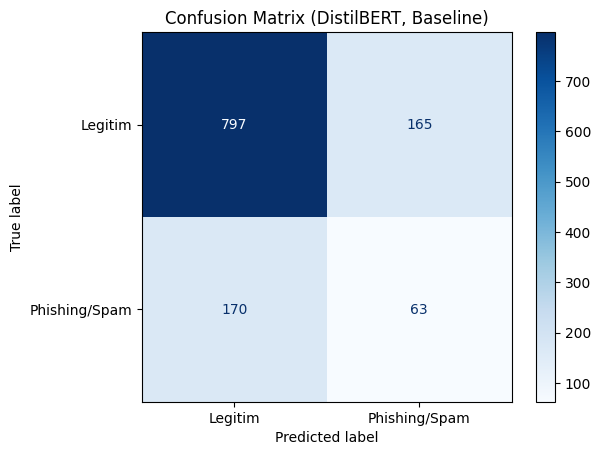

In [6]:
predictions = trainer.predict(test_dataset)
y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(-1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitim", "Phishing/Spam"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (DistilBERT, Baseline)")
plt.show()